In [1]:
import os
import sys
import json
import functools
import multiprocessing as mp
import warnings
from tqdm import tqdm

os.environ["MPLCONFIGDIR"] = "/scratch/tvnguyen/mpl_cache"
sys.path.append('/home/tvnguyen/projects/sbi_twins')
warnings.filterwarnings("ignore")

import corner
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import seaborn as sns

from ml_collections import ConfigDict
from jgnn import utils, datasets, transforms
from dsph_analysis import vdisp, vkurtosis
from dsph_analysis import kinematic_io
from dsph_analysis.sph_model import build_jeans

%matplotlib inline
plt.style.use('~/default.mplstyle')

In [2]:
# Read the run
run_dir = '/scratch/tvnguyen/projects/sbi_dsph/trained_models/npe/8p_ZhaoPlumCOM_v4/qvkcxqc1/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(os.path.join(run_dir, 'config_snapshot.json'), 'r') as f:
    config = ConfigDict(json.load(f))
model, norm_dict = utils.load_npe_from_checkpoint(
    config, os.path.join(run_dir, 'checkpoints/last.ckpt'), verbose=False)
model.eval()
model.to(device)

# set up pre_transforms for the model
# Reason: build_transformation only inserts Normalize(x_loc, x_scale)
# when norm_dict is passed, and config.pre_transforms has no norm_dict
# key. Without it the GNN sees raw features (log10 R ~ -1, vlos ~ 10
# km/s, sigma_v ~ 3) instead of the standardized ones it trained on.
# train_npe.py:260 and eval_utils.py:152 both pass it.
model.pre_transforms = transforms.build_transformation(
    norm_dict=norm_dict, **config.pre_transforms)

[NPE] Flows built from scratch with 328,134 parameters


In [3]:
# Read in test dataset
node_feats, graph_feats = datasets.read_datasets(
    root='/scratch/tvnguyen/projects/sbi_dsph/datasets/',
    name='8p_ZhaoPlumCOM_v4', init=22, num_datasets=1,
)
test_loader, _ = datasets.cartesian.prepare_test_dataloader(
    node_feats, graph_feats, config.labels, cond_labels=config.cond_labels,
    norm_dict=norm_dict, batch_size=512, max_graphs=1000
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.77it/s]
[rank: 0] Seed set to 0
Creating dataloader: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 46572.85it/s]


In [4]:
# Perform inference on the test set, under the same stochastic
# pre_transforms the model was trained with (eval_utils.sample_posterior
# does the same: the calibration then refers to the training
# data-generating process).
theta_scale = np.array(norm_dict['theta_scale'])
theta_loc = np.array(norm_dict['theta_loc'])

# Reason: pre_transforms draws a projection axis, selection mask and
# velocity-error scale per batch at sample time; seed so the test-set
# numbers are reproducible run to run.
torch.manual_seed(0)
np.random.seed(0)

posteriors = model.sample_from_loader(test_loader, num_samples=5000)
posteriors = posteriors.detach().cpu().numpy()
posteriors = posteriors * theta_scale + theta_loc

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:31<00:00, 15.70s/it]


In [5]:
true_theta = np.stack([g.theta.cpu().numpy() for g in test_loader.dataset])[:, 0]
true_theta = true_theta * theta_scale + theta_loc

In [6]:
# The training augmentation is far harsher than any real catalog: up
# to 75% radial dropout, and velocity errors log-uniform up to 5-30
# km/s. Re-run the test set with the selection and uncertainty pinned
# to what the real targets actually look like, to separate "the model
# is bad" from "the evaluation is brutal".
#
# Draco/DESI (dra_desi_memtli_v250331, the catalog npe_inference runs):
# VRAD_ERR median 1.46 km/s, 16-84% 0.45-3.54, with the loader's
# vlos_err_floor = 0.9 km/s -> sigma_v ~ 0.9-3.5 km/s, and 157 members.
# The test galaxies already carry 57-151 stars (median 98), so matching
# the real star counts needs no dropout at all - which is also what
# npe_inference does for real data (apply_selection=False).
OBS_VLOS_ERR_KMS = (0.9, 3.5)

obs_pre_transforms = transforms.build_transformation(
    norm_dict=norm_dict,
    **{
        **config.pre_transforms,
        'apply_selection': False,
        'uncertainty_args': [dict(
            distribution_type='jeffreys', feature_idx=1,
            low=OBS_VLOS_ERR_KMS[0], high=OBS_VLOS_ERR_KMS[1])],
    })

torch.manual_seed(0)
np.random.seed(0)

posteriors_obs = model.sample_from_loader(
    test_loader, num_samples=5000, pre_transforms=obs_pre_transforms)
posteriors_obs = posteriors_obs.detach().cpu().numpy()
posteriors_obs = posteriors_obs * theta_scale + theta_loc

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:30<00:00, 15.10s/it]


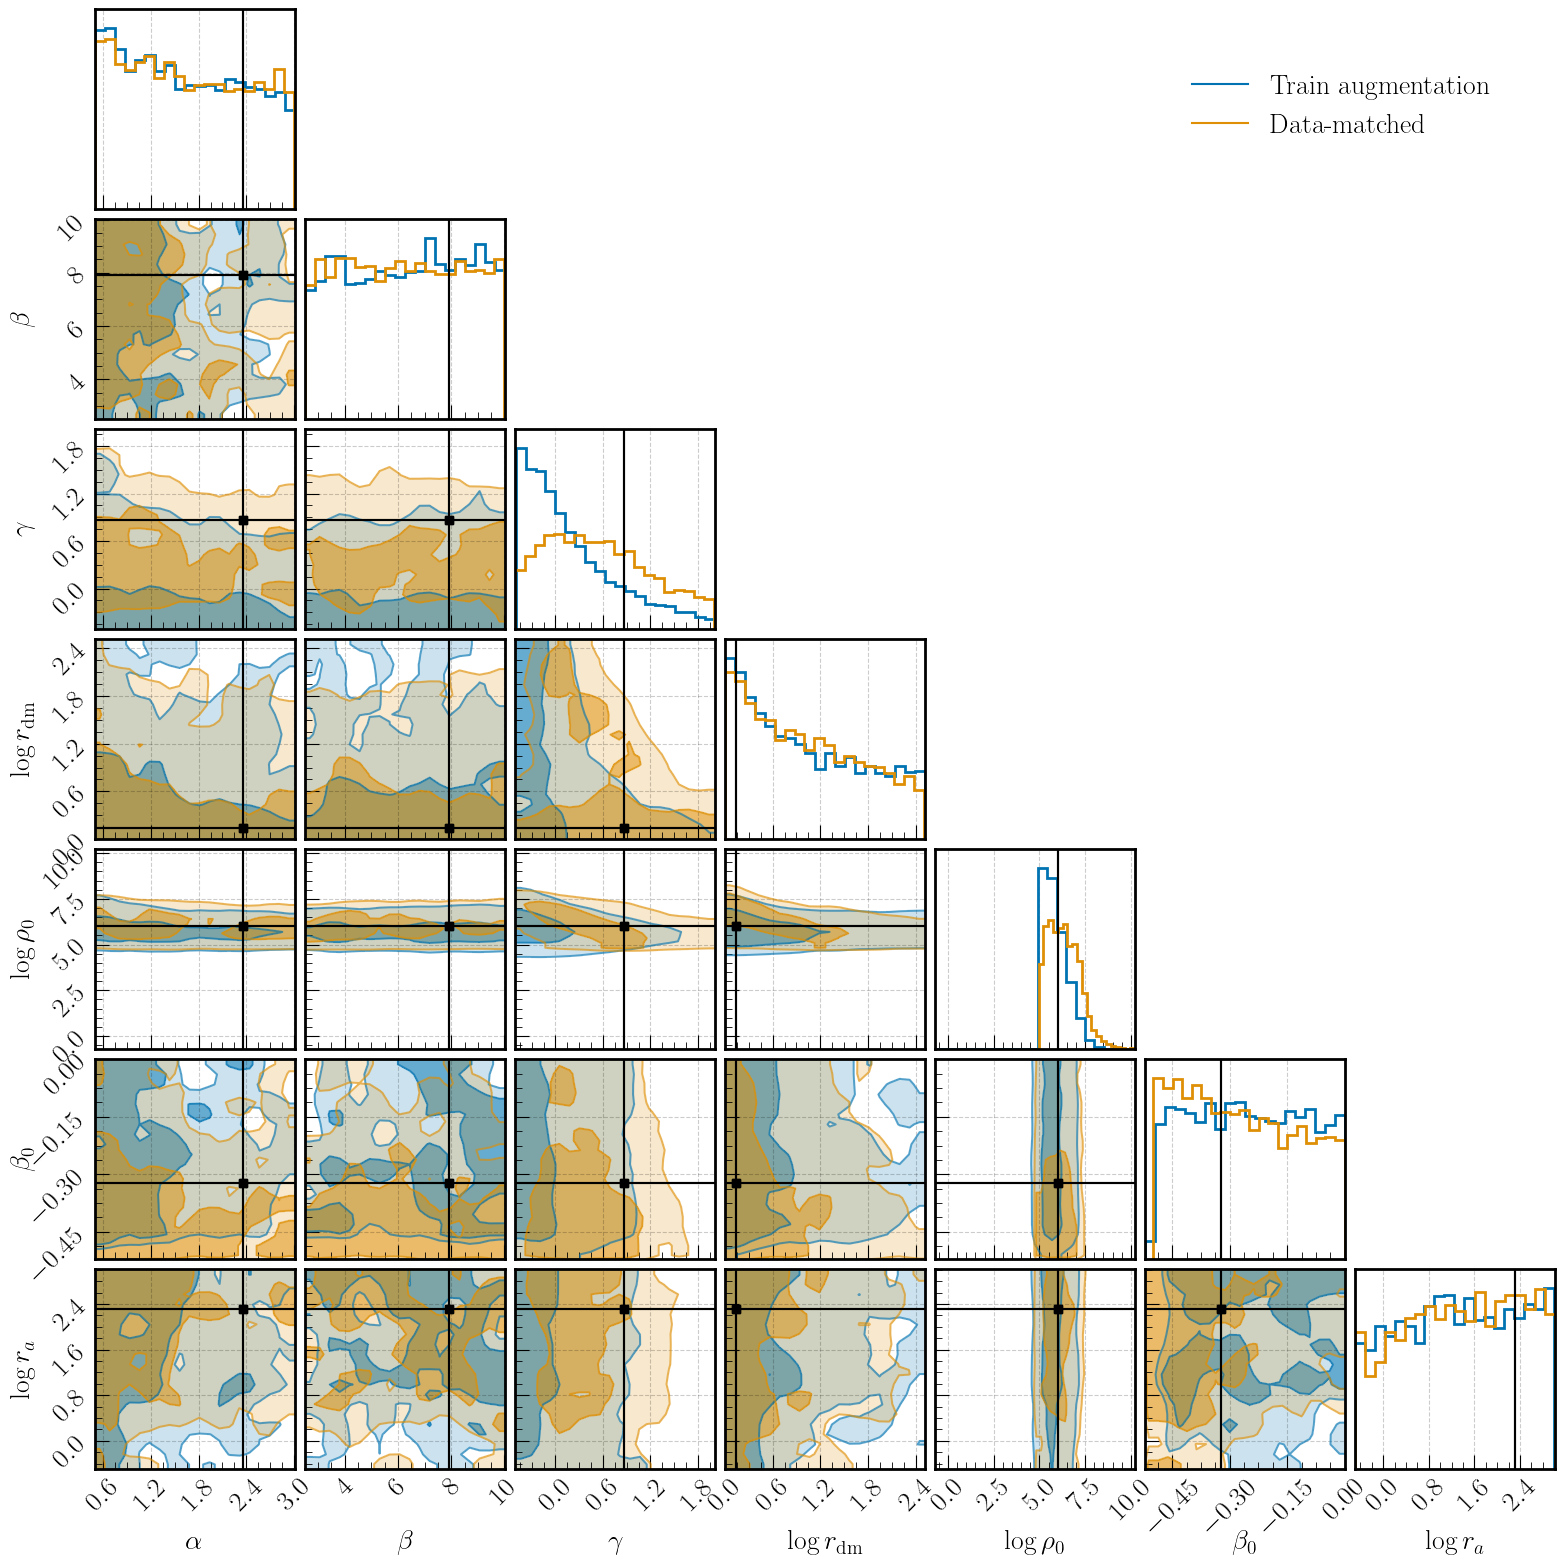

In [13]:
# Example posterior for one test-set galaxy.
example_idx = 12

LABEL_TEX = {
    'dm_alpha': r'$\alpha$',
    'dm_beta': r'$\beta$',
    'dm_gamma': r'$\gamma$',
    'dm_log_rdm': r'$\log r_{\rm dm}$',
    'dm_log_rho0': r'$\log \rho_0$',
    'df_beta0': r'$\beta_0$',
    'df_log_ra': r'$\log r_a$',
}
color_pallette = sns.color_palette('colorblind', n_colors=2)
color = color_pallette[0]

RUNS = {
    'Train augmentation': posteriors,
    'Data-matched': posteriors_obs,
}

corner_kwargs = dict(
    # standard 1- and 2-sigma 2D contours (corner.corner's own default
    # formula), well resolved at n=5000.
    levels=tuple(1.0 - np.exp(-0.5 * np.array([1.0, 2.0]) ** 2)),
    labels=[LABEL_TEX[name] for name in config.labels],
    truths=true_theta[example_idx],
    truth_color='black',
    plot_datapoints=False,
    fill_contours=True,
    no_fill_contours=True,
    smooth=1.0,
)

fig = None
for i, (label, post) in enumerate(RUNS.items()):
    # Reason: a fresh hist_kwargs per call, with the solid colour.
    # corner.corner mutates the dict it is handed (it writes 'color'
    # into it), so a shared dict leaves every diagonal panel in the
    # first run's colour; and the contour colour carries alpha=0.6,
    # which washes out step lines that never occlude each other.
    fig = corner.corner(
        post[example_idx], color=(*color_pallette[i], 0.6), fig=fig,
        hist_kwargs=dict(density=True, lw=2, color=color_pallette[i]),
        **corner_kwargs)

fig.legend(
    handles=[mpl.lines.Line2D([], [], color=color_pallette[i], label=label)
             for i, label in enumerate(RUNS)],
    loc='upper right', bbox_to_anchor=(0.95, 0.95), frameon=False,
)

In [8]:
from sbi_twins import priors

MAX_WORKERS = 38  # Reason: the cgroup caps this account at 38 cores.
TO_MSUN = 1e7      # sph_model works in units of 1e7 Msun


def _npe_profiles_one(
    row: np.ndarray,
    radius: np.ndarray
) -> tuple[np.ndarray, ...]:
    """
    Derived Jeans profiles for one NPE posterior sample.

    Args:
        row: [theta (7,), cond (1,)] concatenated in
            sbi_twins.priors.PARAM_NAMES order.
        radius: Radii to evaluate the profiles at [kpc].

    Returns:
        (rho, mass, beta, sigma2_los, kurtosis_los) at each radius.
    """
    model = build_jeans(priors.to_jeans_theta(row))
    return (model.rho(radius) * TO_MSUN, model.M(radius) * TO_MSUN,
            model.beta(radius), model.sigma2_los(radius),
            model.kurtosis_los(radius))


def calc_npe_profiles(
    theta: np.ndarray,
    cond: np.ndarray,
    radius: np.ndarray,
    n_workers: int | None = None
) -> tuple[np.ndarray, ...]:
    """
    Derived profiles for every NPE posterior sample, in parallel.

    Args:
        theta: Posterior samples in config.labels order, shape
            (n_samples, 7).
        cond: The galaxy's fixed stellar_log_rstar_kpc, shape (1,).
        radius: Radii to evaluate the profiles at [kpc].
        n_workers: Processes to use; None picks min(38, n_cpus).

    Returns:
        (rho_dm, mass_dm, beta_ani, sigma2_los, kurtosis_los), each of
        shape (n_samples, len(radius)).
    """
    rows = np.concatenate(
        [theta, np.tile(cond, (len(theta), 1))], axis=1)
    work = functools.partial(_npe_profiles_one, radius=radius)
    if n_workers is None:
        n_workers = min(MAX_WORKERS, len(os.sched_getaffinity(0)),
                        len(rows))

    if n_workers == 1:
        results = [work(row) for row in tqdm(rows)]
    else:
        with mp.get_context('fork').Pool(n_workers) as pool:
            results = list(tqdm(pool.imap(work, rows, chunksize=8),
                                total=len(rows)))

    return tuple(np.stack(profile) for profile in zip(*results))


# The example galaxy's stellar half-light radius is observed data, so
# it is the same for every posterior sample.
cond_scale = np.array(norm_dict['cond_scale'])
cond_loc = np.array(norm_dict['cond_loc'])
true_cond = (test_loader.dataset[example_idx].cond.cpu().numpy()[0]
             * cond_scale + cond_loc)
r_star = 10 ** true_cond[0]

radius = np.logspace(np.log10(0.1 * r_star), np.log10(10 * r_star), 40)

N_PROFILE_SAMPLES = 200
profiles = calc_npe_profiles(
    posteriors[example_idx][:N_PROFILE_SAMPLES], true_cond, radius,
    n_workers=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 311.96it/s]


In [9]:
_truth_row = np.concatenate([true_theta[example_idx], true_cond])
_truth_model = build_jeans(priors.to_jeans_theta(_truth_row))
true_profile = _npe_profiles_one(_truth_row, radius)

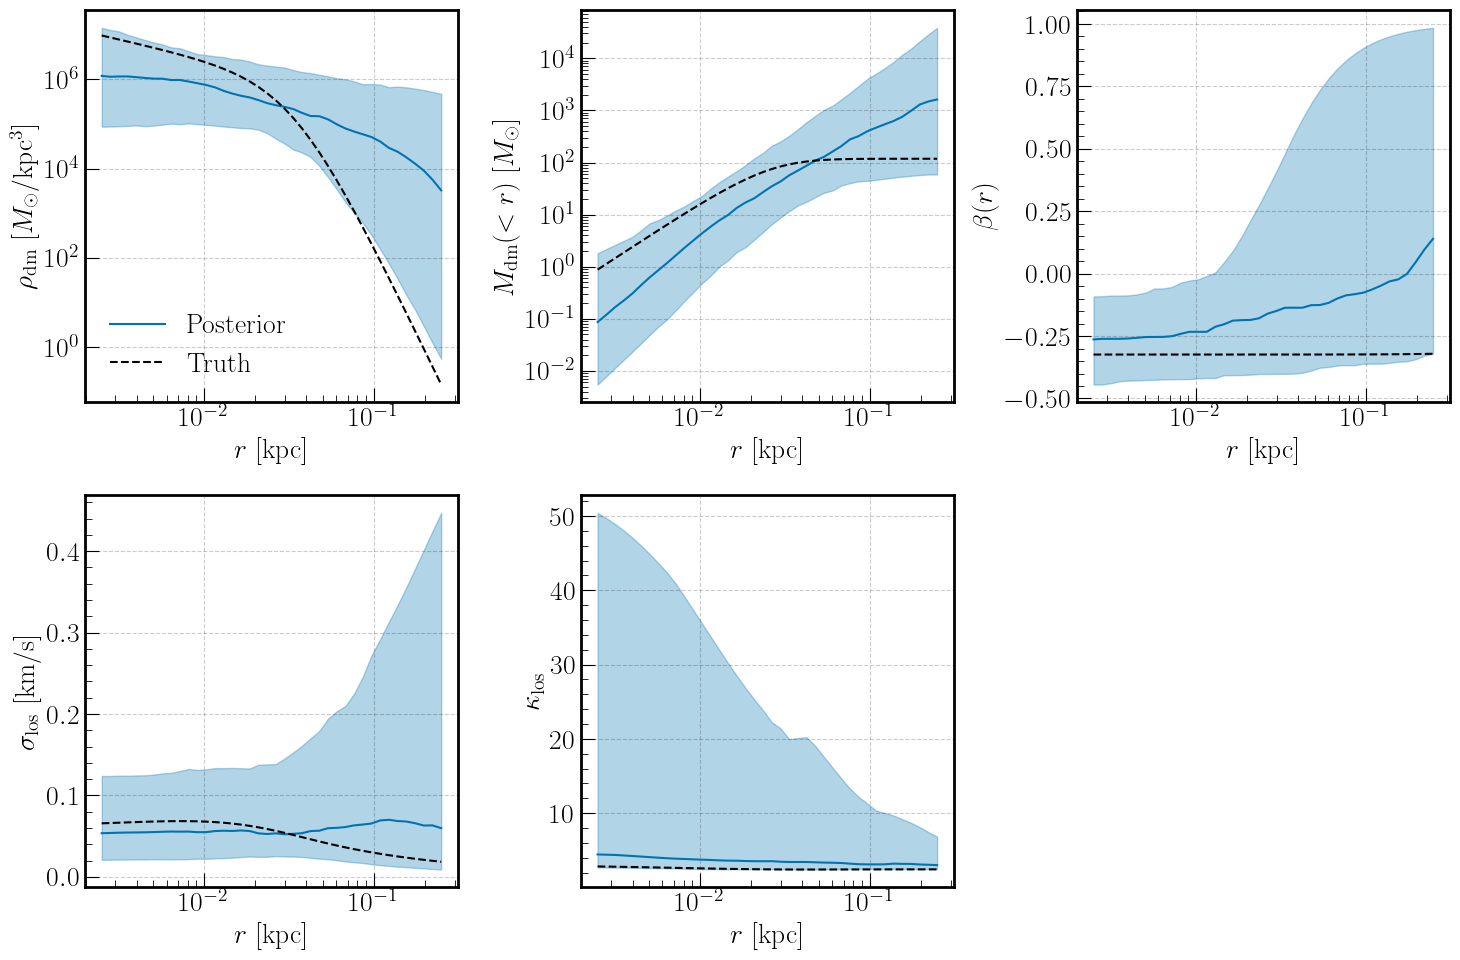

In [10]:
# Plot the profiles with a 68% posterior band, one panel per physical
# quantity.
PROFILE_SPECS = [
    (0, r'$\rho_{\rm dm}$ [$M_\odot$/kpc$^3$]', True, False),
    (1, r'$M_{\rm dm}(<r)$ [$M_\odot$]', True, False),
    (2, r'$\beta(r)$', False, False),
    (3, r'$\sigma_{\rm los}$ [km/s]', False, True),
    (4, r'$\kappa_{\rm los}$', False, False),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (i, ylabel, logy, sqrt) in zip(axes, PROFILE_SPECS):
    p = profiles[i]
    p = np.sqrt(p) if sqrt else p
    lo68, med, hi68 = np.percentile(p, [16, 50, 84], axis=0)
    ax.fill_between(radius, lo68, hi68, color=color, alpha=0.3)
    ax.plot(radius, med, color=color, label='Posterior')

    truth = true_profile[i]
    truth = np.sqrt(truth) if sqrt else truth
    ax.plot(radius, truth, color='black', ls='--', label='Truth')

    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_ylabel(ylabel)

axes[0].legend(frameon=False)
for ax in axes[len(PROFILE_SPECS):]:
    ax.set_visible(False)
fig.tight_layout()

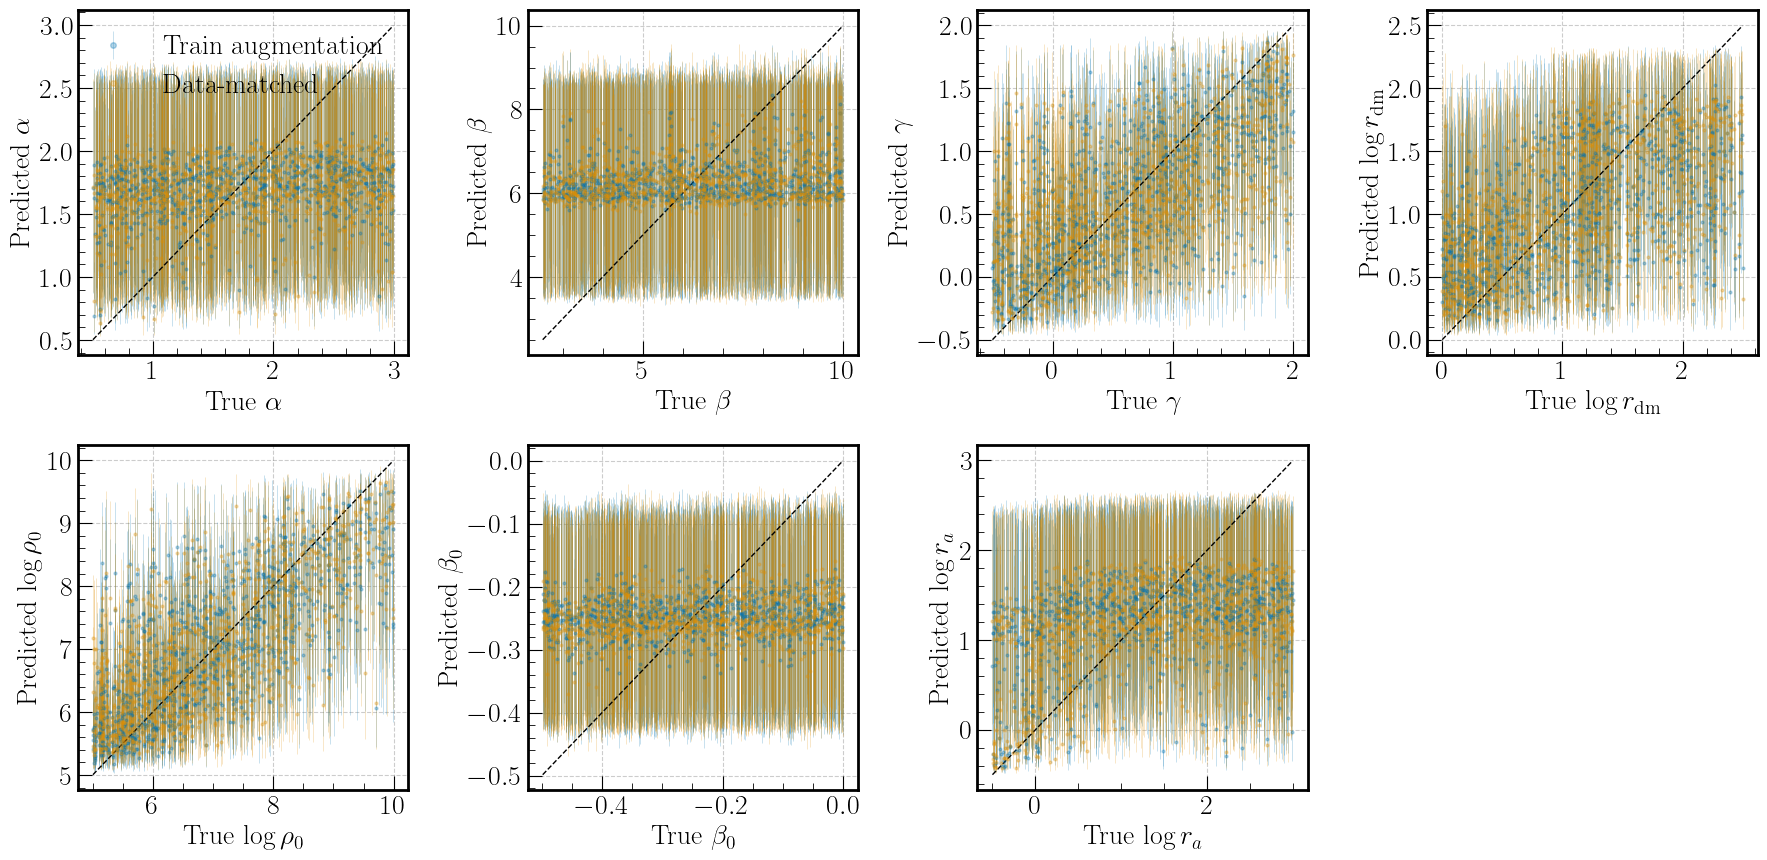

parameter        Train augmentation         Data-matched
dm_alpha                      0.572                0.578
dm_beta                       0.574                0.575
dm_gamma                      0.440                0.447
dm_log_rdm                    0.486                0.476
dm_log_rho0                   0.368                0.372
df_beta0                      0.580                0.571
df_log_ra                     0.549                0.538


In [11]:
# Predicted (posterior median +/- 68%) vs true, across the whole test
# set, under the training augmentation and under the data-matched
# selection/uncertainty.
medians = {label: np.median(post, axis=1) for label, post in RUNS.items()}

n_params = len(config.labels)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, name in enumerate(config.labels):
    ax = axes[i]
    for j, (label, post) in enumerate(RUNS.items()):
        med = medians[label][:, i]
        yerr = np.stack([med - np.percentile(post[:, :, i], 16, axis=1),
                         np.percentile(post[:, :, i], 84, axis=1) - med])
        ax.errorbar(true_theta[:, i], med, yerr=yerr, fmt='.', ms=4,
                   lw=0.5, alpha=0.3, color=color_pallette[j], label=label)
    lo, hi = true_theta[:, i].min(), true_theta[:, i].max()
    ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--')
    ax.set_xlabel('True ' + LABEL_TEX[name])
    ax.set_ylabel('Predicted ' + LABEL_TEX[name])

axes[0].legend(frameon=False, markerscale=2)
for ax in axes[n_params:]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

# RMSE of the posterior median, in units of the prior half-width, so
# the seven parameters are on a common scale.
print(f'{"parameter":<14s} ' + ' '.join(f'{lab:>20s}' for lab in RUNS))
for i, name in enumerate(config.labels):
    row = [np.sqrt(np.mean((medians[lab][:, i] - true_theta[:, i]) ** 2))
           / theta_scale[i] for lab in RUNS]
    print(f'{name:<14s} ' + ' '.join(f'{v:>20.3f}' for v in row))

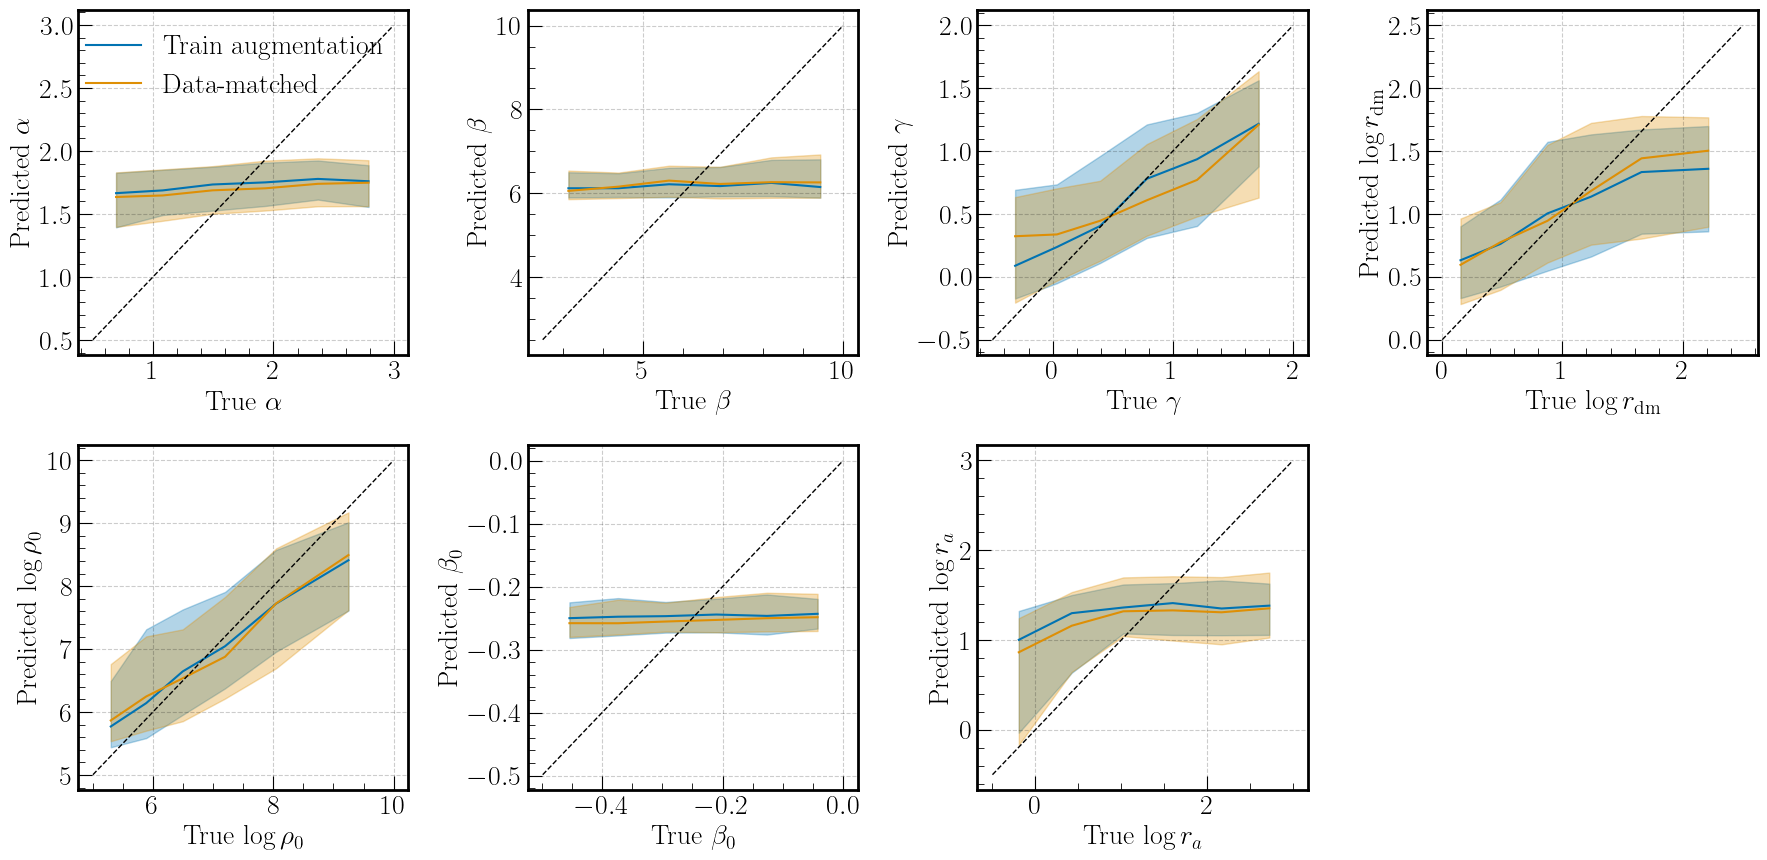

In [12]:
# Same comparison, but binned by the true value: median and 68% band of
# the posterior medians within each bin.
N_BINS = 6

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, name in enumerate(config.labels):
    ax = axes[i]
    edges = np.percentile(true_theta[:, i], np.linspace(0, 100, N_BINS + 1))
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.clip(
        np.digitize(true_theta[:, i], edges[1:-1]), 0, N_BINS - 1)

    for j, label in enumerate(RUNS):
        pred = medians[label][:, i]
        lo, med, hi = np.array([
            np.percentile(pred[bin_idx == b], [16, 50, 84])
            for b in range(N_BINS)]).T
        ax.fill_between(centers, lo, hi, color=color_pallette[j], alpha=0.3)
        ax.plot(centers, med, color=color_pallette[j], label=label)

    lo_t, hi_t = true_theta[:, i].min(), true_theta[:, i].max()
    ax.plot([lo_t, hi_t], [lo_t, hi_t], color='black', lw=1, ls='--')
    ax.set_xlabel('True ' + LABEL_TEX[name])
    ax.set_ylabel('Predicted ' + LABEL_TEX[name])

axes[0].legend(frameon=False)
for ax in axes[len(config.labels):]:
    ax.set_visible(False)
fig.tight_layout()